# Data Inspection - King County House Sales Dataset

**Project:** Geospatial Valuation
**Task:** Inspect the dataset *exactly as received* from Kaggle before any EDA or preprocessing

**Dataset:** King County (Seattle area, WA) House Sales — `kc_house_data.csv`

**Scope of this notebook:** this notebook only describes and flags issues in the raw dataset (shape, types, missing values, duplicates, raw-data quirks, per-column distributions/outliers). It does **not**:
- relate any feature to `price` (no correlation analysis, no groupby-by-target)
- transform, clean, or convert any column (e.g. no fixing `sqft_basement`, no log-transform of price)
- engineer any new/derived column (e.g. no parsed date, no renovated flag)

Those steps belong to separate **EDA** and **Preprocessing** notebooks, which may be owned by other team members and depend on the findings recorded here.


### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# to handle input file(s)
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


### 2. Load Dataset

In [2]:
# csv file path (to resolve problem at production level)
BASE_DIR = Path().resolve()

candidate_paths = [
    BASE_DIR / 'kc_house_data.csv',
    BASE_DIR.parent / 'Dataset' / 'kc_house_data.csv',
    BASE_DIR / 'Dataset' / 'kc_house_data.csv',
    Path('/mnt/project/kc_house_data.csv'),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("kc_house_data.csv not found in any expected location")

df = pd.read_csv(csv_path)
print("Dataset loaded successfully from:", csv_path)
print("Shape:", df.shape)


Dataset loaded successfully from: /home/claude/proj/kc_house_data.csv
Shape: (21597, 21)


### 3. First Look

In [3]:
print("First 5 rows:\n")
df.head()


First 5 rows:



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900,3,1.00,1180,5650,1.0,NaN,0.0,3,7,1180,0,1955,0.0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000,3,2.25,2570,7242,2.0,0.0,0.0,3,7,2170,400,1951,1991.0,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000,2,1.00,770,10000,1.0,0.0,0.0,3,6,770,0,1933,NaN,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000,4,3.00,1960,5000,1.0,0.0,0.0,5,7,1050,910,1965,0.0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000,3,2.00,1680,8080,1.0,0.0,0.0,3,8,1680,0,1987,0.0,98074,47.6168,-122.045,1800,7503


In [4]:
print("Column names and data types:\n")
print(df.dtypes)
print()
df.info()


Column names and data types:

id                 int64
date                 str
price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement        str
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  int64  
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    2159

### 4. Basic Statistics

In [5]:
print("Statistical Summary (numeric + object columns):\n")
df.describe(include='all').T


Statistical Summary (numeric + object columns):



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21597.0,NaN,NaN,NaN,4580474287.770987,2876735715.74778,1000102.0,2123049175.0,3904930410.0,7308900490.0,9900000190.0
date,21597,372,6/23/2014,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21597.0,NaN,NaN,NaN,540296.573506,367368.140101,78000.0,322000.0,450000.0,645000.0,7700000.0
bedrooms,21597.0,NaN,NaN,NaN,3.3732,0.926299,1.0,3.0,3.0,4.0,33.0
bathrooms,21597.0,NaN,NaN,NaN,2.115826,0.768984,0.5,1.75,2.25,2.5,8.0
sqft_living,21597.0,NaN,NaN,NaN,2080.32185,918.106125,370.0,1430.0,1910.0,2550.0,13540.0
sqft_lot,21597.0,NaN,NaN,NaN,15099.40876,41412.636876,520.0,5040.0,7618.0,10685.0,1651359.0
floors,21597.0,NaN,NaN,NaN,1.494096,0.539683,1.0,1.0,1.5,2.0,3.5
waterfront,19221.0,NaN,NaN,NaN,0.007596,0.086825,0.0,0.0,0.0,0.0,1.0
view,21534.0,NaN,NaN,NaN,0.233863,0.765686,0.0,0.0,0.0,0.0,4.0


### 5. Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

print("Missing values per column:\n")
print(missing_df if len(missing_df) else "No missing values found")
print()
print("Total missing values:", missing.sum())


Missing values per column:

              missing_count  missing_pct
yr_renovated           3842        17.79
waterfront             2376        11.00
view                     63         0.29

Total missing values: 6281


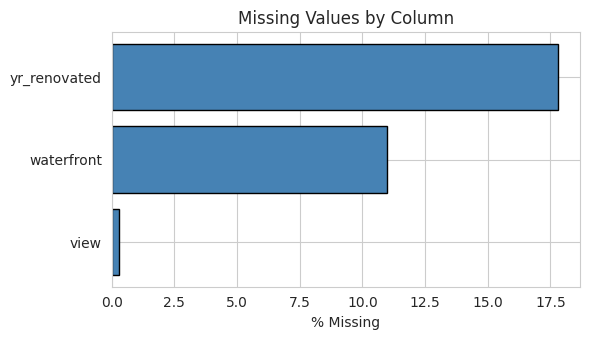

In [7]:
if len(missing_df):
    plt.figure(figsize=(6, 3.5))
    plt.barh(missing_df.index, missing_df['missing_pct'], color='steelblue', edgecolor='black')
    plt.xlabel('% Missing')
    plt.title('Missing Values by Column')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot - no missing values.")


### 6. Duplicate Rows & Repeated Property IDs

In [8]:
print("Fully duplicate rows:", df.duplicated().sum())
print()

# 'id' identifies the property/parcel - the same house can legitimately appear
# more than once if it was sold more than once during the collection window.
# This is a characteristic of the raw data, noted here, not resolved here.
dup_ids = df['id'].duplicated().sum()
print("Rows with a repeated property 'id' (re-sold houses):", dup_ids)
if dup_ids:
    example_id = df[df['id'].duplicated(keep=False)]['id'].iloc[0]
    print()
    print(f"Example - property id {example_id} appears more than once:")
    print(df[df['id'] == example_id][['id', 'date', 'price']])


Fully duplicate rows: 0

Rows with a repeated property 'id' (re-sold houses): 177

Example - property id 6021501535 appears more than once:
            id        date   price
93  6021501535   7/25/2014  430000
94  6021501535  12/23/2014  700000


### 7. Raw Data Quirks (flagged only, not fixed)

These are quirks specific to this dataset, noted here for whoever owns preprocessing. Nothing is converted or corrected in this notebook.


In [9]:
# 'sqft_basement' is stored as text and contains '?' placeholders instead of NaN
print("Unique non-numeric-looking values in 'sqft_basement':")
non_numeric = df['sqft_basement'][~df['sqft_basement'].str.replace('.', '', 1).str.isnumeric()]
print(non_numeric.value_counts())
print()
print("Note: column dtype is left as-is (object/text) - no conversion performed here.")


Unique non-numeric-looking values in 'sqft_basement':
sqft_basement
?    454
Name: count, dtype: int64

Note: column dtype is left as-is (object/text) - no conversion performed here.


In [10]:
# 'yr_renovated' uses 0 to mean "never renovated" rather than NaN - flagged, not recoded
never_renovated = (df['yr_renovated'] == 0).sum()
renovated = (df['yr_renovated'] > 0).sum()
unknown_renovated = df['yr_renovated'].isnull().sum()

print("yr_renovated == 0 (never renovated, per raw encoding):", never_renovated)
print("yr_renovated > 0 (renovated, year given):", renovated)
print("yr_renovated missing:", unknown_renovated)


yr_renovated == 0 (never renovated, per raw encoding): 17011
yr_renovated > 0 (renovated, year given): 744
yr_renovated missing: 3842


In [11]:
# Structural values worth flagging before modelling - listed only, not removed/capped
print("Rows with bedrooms > 10:")
print(df[df['bedrooms'] > 10][['id', 'bedrooms', 'bathrooms', 'sqft_living', 'price']])
print()
print("Rows with bedrooms == 0:", (df['bedrooms'] == 0).sum())
print("Rows with bathrooms == 0:", (df['bathrooms'] == 0).sum())


Rows with bedrooms > 10:
               id  bedrooms  bathrooms  sqft_living   price
8748   1773100755        11       3.00         3000  520000
15856  2402100895        33       1.75         1620  640000

Rows with bedrooms == 0: 0
Rows with bathrooms == 0: 0


### 8. Target Variable - Price (distribution only, no transformation)

In [12]:
print("Price - Summary Statistics:\n")
print(df['price'].describe())
print()
print("Skewness:", round(df['price'].skew(), 2))
print("(Whether/how to transform price is a preprocessing decision, out of scope here.)")


Price - Summary Statistics:

count    2.159700e+04
mean     5.402966e+05
std      3.673681e+05
min      7.800000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

Skewness: 4.02
(Whether/how to transform price is a preprocessing decision, out of scope here.)


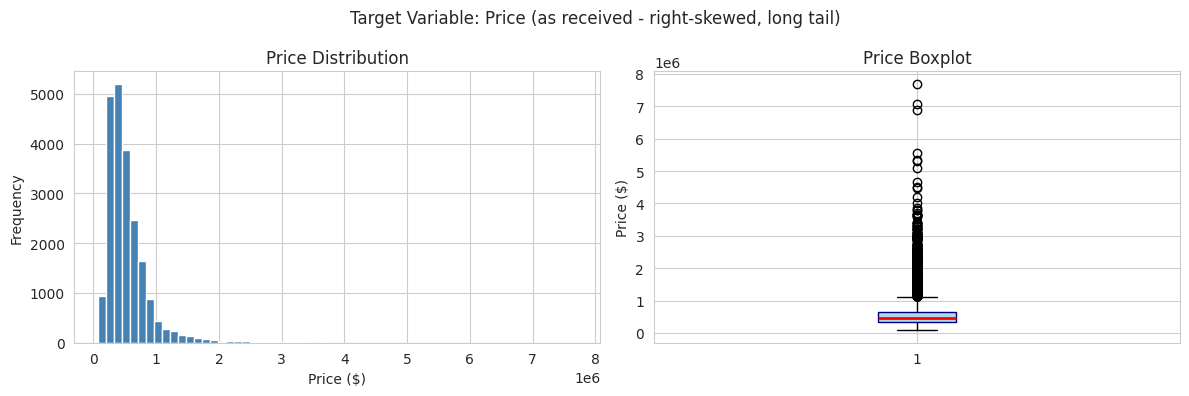

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['price'], patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Target Variable: Price (as received - right-skewed, long tail)')
plt.tight_layout()
plt.show()


### 9. Structural Feature Distributions (univariate, raw values)

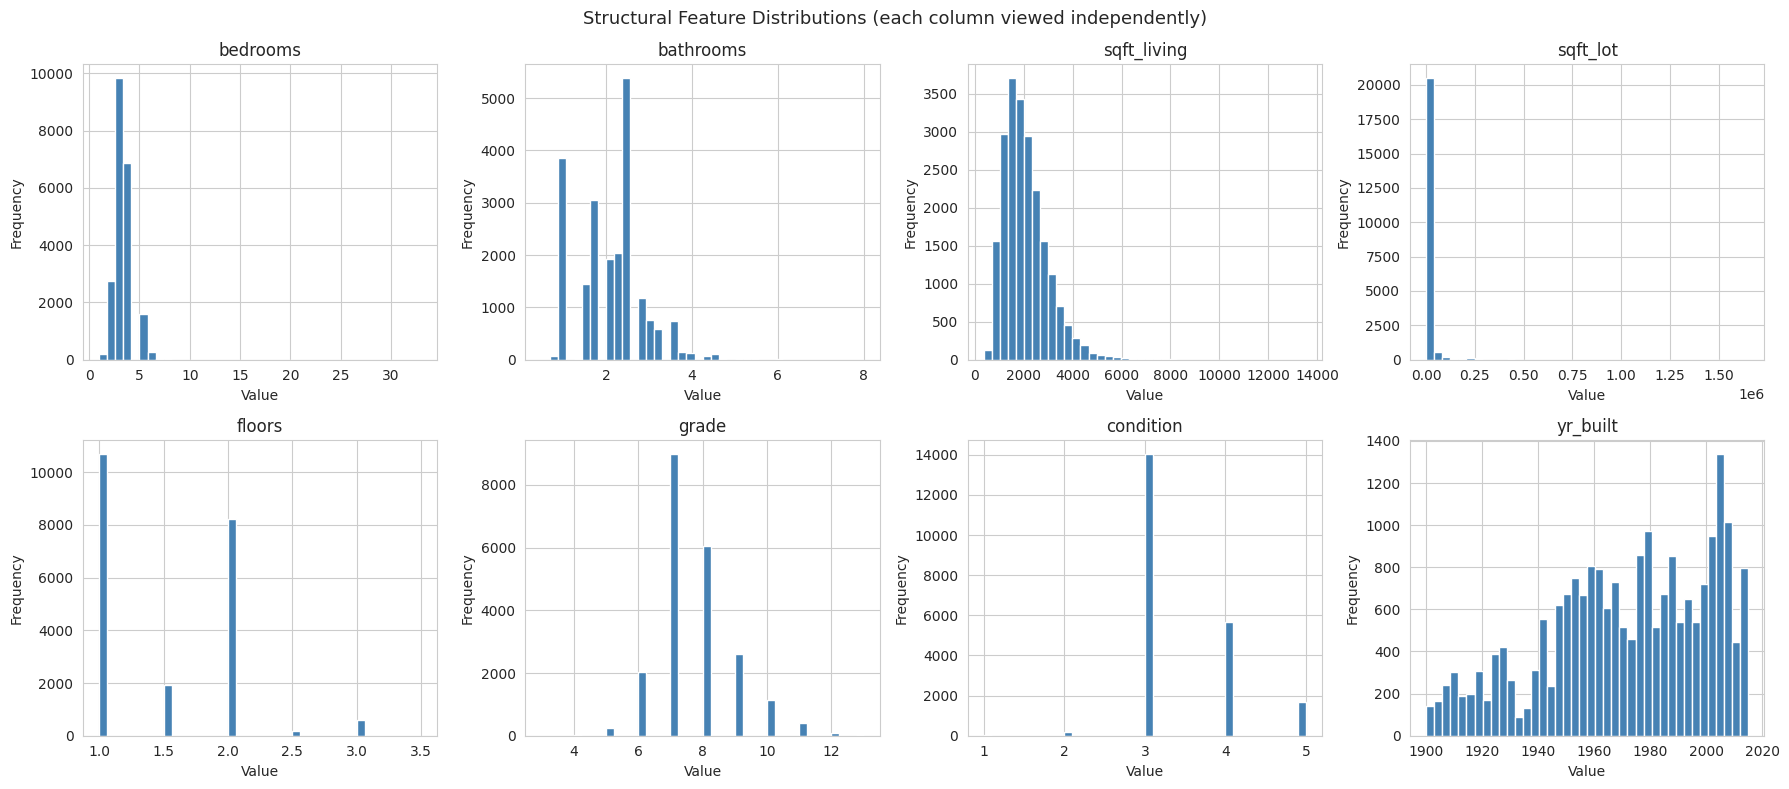

In [14]:
num_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                'floors', 'grade', 'condition', 'yr_built']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Structural Feature Distributions (each column viewed independently)', fontsize=13)
plt.tight_layout()
plt.show()


### 10. Categorical / Discrete Feature Counts (no relationship to price)

In [15]:
print("Waterfront - Value Counts:\n")
print(df['waterfront'].value_counts(dropna=False))
print()
print("View score - Value Counts:\n")
print(df['view'].value_counts(dropna=False))
print()
print("Condition - Value Counts:\n")
print(df['condition'].value_counts())
print()
print("Grade - Value Counts:\n")
print(df['grade'].value_counts().sort_index())


Waterfront - Value Counts:

waterfront
0.0    19075
NaN     2376
1.0      146
Name: count, dtype: int64

View score - Value Counts:

view
0.0    19422
2.0      957
3.0      508
1.0      330
4.0      317
NaN       63
Name: count, dtype: int64

Condition - Value Counts:

condition
3    14020
4     5677
5     1701
2      170
1       29
Name: count, dtype: int64

Grade - Value Counts:

grade
3        1
4       27
5      242
6     2038
7     8974
8     6065
9     2615
10    1134
11     399
12      89
13      13
Name: count, dtype: int64


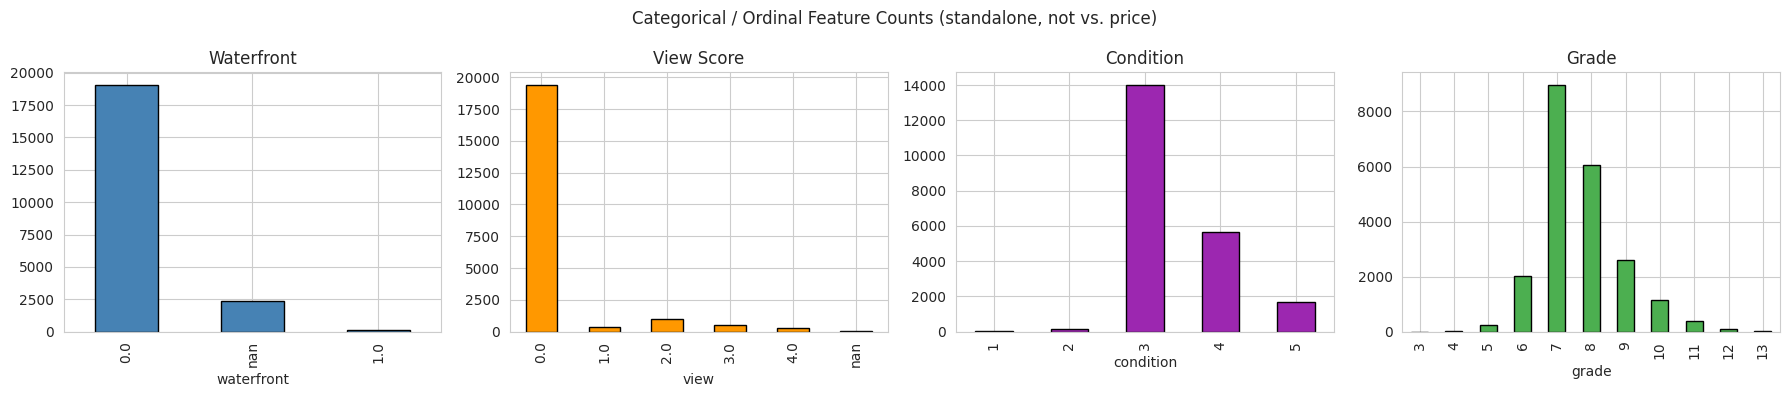

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

df['waterfront'].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Waterfront')

df['view'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[1], color='#FF9800', edgecolor='black')
axes[1].set_title('View Score')

df['condition'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#9C27B0', edgecolor='black')
axes[2].set_title('Condition')

df['grade'].value_counts().sort_index().plot(kind='bar', ax=axes[3], color='#4CAF50', edgecolor='black')
axes[3].set_title('Grade')

plt.suptitle('Categorical / Ordinal Feature Counts (standalone, not vs. price)')
plt.tight_layout()
plt.show()


### 11. Outlier Check (IQR Method, per column - no removal/capping)

In [17]:
outlier_features = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms']

print("Outliers per feature (IQR method):\n")
for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


Outliers per feature (IQR method):

price: 1158 outliers (5.4%)
sqft_living: 571 outliers (2.6%)
sqft_lot: 2419 outliers (11.2%)
bedrooms: 530 outliers (2.5%)
bathrooms: 561 outliers (2.6%)


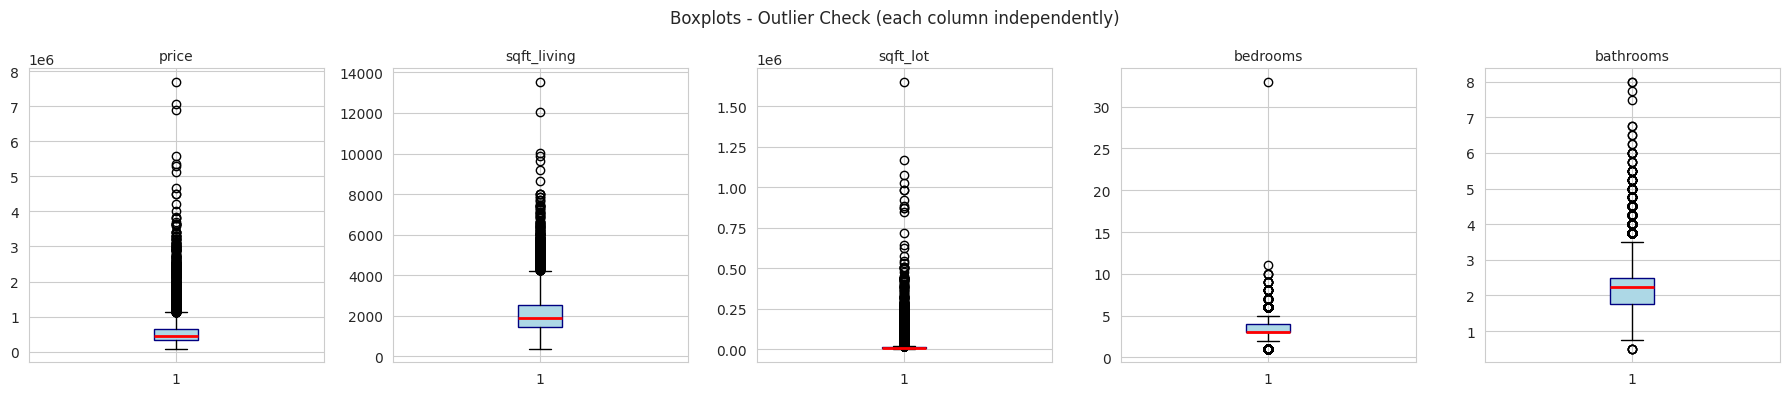

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(outlier_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Boxplots - Outlier Check (each column independently)')
plt.tight_layout()
plt.show()


### 12. Geospatial Field Validity Check

Checking that the location fields themselves are well-formed and in-range - **not** how location relates to price (that belongs in EDA).


In [19]:
print("Latitude range: ", df['lat'].min(), "to", df['lat'].max())
print("Longitude range:", df['long'].min(), "to", df['long'].max())
print()
# Sanity check: King County, WA roughly spans lat 47.1-47.8, long -122.5 to -121.3
king_county_bounds = {'lat': (47.0, 47.9), 'long': (-122.6, -121.0)}
out_of_bounds = df[
    (df['lat'] < king_county_bounds['lat'][0]) | (df['lat'] > king_county_bounds['lat'][1]) |
    (df['long'] < king_county_bounds['long'][0]) | (df['long'] > king_county_bounds['long'][1])
]
print("Rows with lat/long outside expected King County bounds:", len(out_of_bounds))


Latitude range:  47.1559 to 47.7776
Longitude range: -122.519 to -121.315

Rows with lat/long outside expected King County bounds: 0


In [20]:
print("Number of unique zipcodes:", df['zipcode'].nunique())
print()
zip_counts = df['zipcode'].value_counts()
print("Top 10 zipcodes by number of records (frequency only):\n")
print(zip_counts.head(10))


Number of unique zipcodes: 70

Top 10 zipcodes by number of records (frequency only):

zipcode
98103    602
98038    589
98115    583
98052    574
98117    553
98042    547
98034    545
98118    507
98023    499
98006    498
Name: count, dtype: int64


### 13. Raw Date Field Check

In [21]:
print("Sample raw 'date' values:\n")
print(df['date'].head(10))
print()
print("Unique date string formats/lengths seen:", df['date'].str.len().unique())
print("Number of unique dates:", df['date'].nunique())
print()
print("Note: 'date' is left as the original string column here;")
print("parsing it into a real datetime / deriving sale_year, sale_month is a preprocessing step.")


Sample raw 'date' values:

0    10/13/2014
1     12/9/2014
2     2/25/2015
3     12/9/2014
4     2/18/2015
5     5/12/2014
6     6/27/2014
7     1/15/2015
8     4/15/2015
9     3/12/2015
Name: date, dtype: str

Unique date string formats/lengths seen: [10  9  8]
Number of unique dates: 372

Note: 'date' is left as the original string column here;
parsing it into a real datetime / deriving sale_year, sale_month is a preprocessing step.


### Result

In [22]:
print("Inspection Summary")
print("-" * 45)
print(f"Rows                    : {df.shape[0]}")
print(f"Columns                 : {df.shape[1]}")
print(f"Unique properties (id)  : {df['id'].nunique()}")
print(f"Repeat-id rows          : {df['id'].duplicated().sum()}")
print(f"Total missing values    : {df.isnull().sum().sum()}")
print(f"Fully duplicate rows    : {df.duplicated().sum()}")
print(f"Price range             : ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")
print(f"Price skewness          : {df['price'].skew():.2f}")
print(f"Unique zipcodes         : {df['zipcode'].nunique()}")
print()
print("Raw-data issues flagged for preprocessing:")
print("- 'sqft_basement' stored as text with '?' placeholders (needs numeric conversion)")
print("- 'yr_renovated' uses 0 as a sentinel for 'never renovated' (needs an explicit flag/encoding)")
print("- 'waterfront' and 'view' have missing values (needs an imputation/handling decision)")
print("- one record has 33 bedrooms - very likely a data-entry error, needs review")
print("- 'id' repeats for houses sold more than once (needs a decision: keep all sales, or one row per property)")
print("- 'date' is a raw string and not yet parsed into a usable datetime")
print()
print("No target-relationship analysis (correlation, price-by-location, price-by-feature) was")
print("performed in this notebook - that is in scope for the separate EDA notebook.")


Inspection Summary
---------------------------------------------
Rows                    : 21597
Columns                 : 21
Unique properties (id)  : 21420
Repeat-id rows          : 177
Total missing values    : 6281
Fully duplicate rows    : 0
Price range             : $78,000 - $7,700,000
Price skewness          : 4.02
Unique zipcodes         : 70

Raw-data issues flagged for preprocessing:
- 'sqft_basement' stored as text with '?' placeholders (needs numeric conversion)
- 'yr_renovated' uses 0 as a sentinel for 'never renovated' (needs an explicit flag/encoding)
- 'waterfront' and 'view' have missing values (needs an imputation/handling decision)
- one record has 33 bedrooms - very likely a data-entry error, needs review
- 'id' repeats for houses sold more than once (needs a decision: keep all sales, or one row per property)
- 'date' is a raw string and not yet parsed into a usable datetime

No target-relationship analysis (correlation, price-by-location, price-by-feature) was
per

**Conclusion:** This notebook inspected `kc_house_data.csv` exactly as received: its structure, types, missing values, duplicates/repeat IDs, dataset-specific raw-data quirks, and per-column distributions/outliers - including a validity check on the geospatial fields (`lat`, `long`, `zipcode`). No column was transformed, cleaned, or engineered, and no feature was analyzed against `price`. The issues listed in the Result section above are handed off as-is to the **EDA** notebook (feature relationships, correlation, price-by-location patterns) and the **Preprocessing** notebook (cleaning `sqft_basement`, encoding `yr_renovated`, handling missing values, deciding on repeat-sale rows, parsing `date`), which may be owned by other team members.
